# Vision Transformer from scratch


## Load the dataset and resize them

torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([3, 144, 144])
torch.Size([

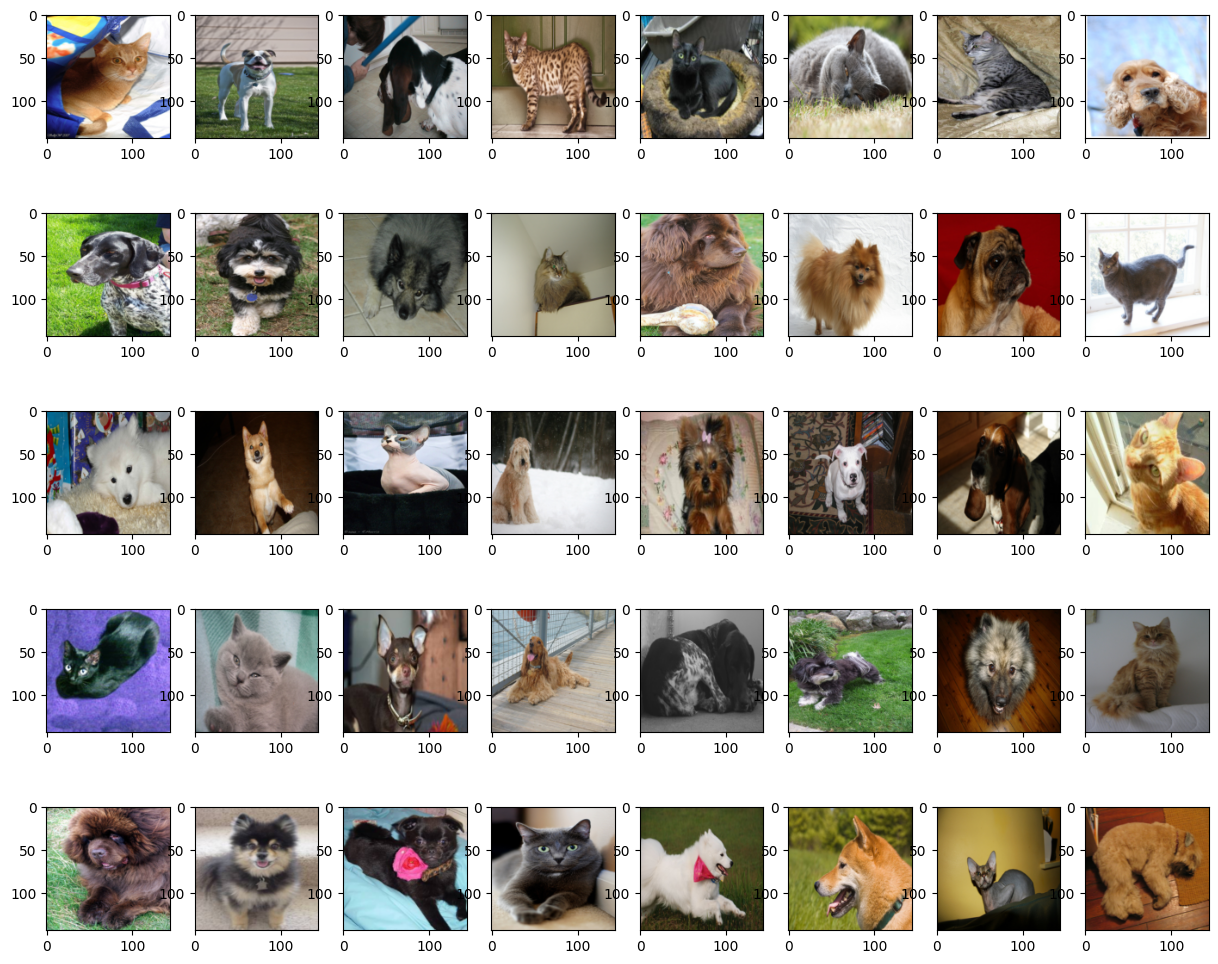

In [10]:
import torch
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
from random import random
from torchvision.transforms import Resize, ToTensor
from torchvision.transforms.functional import to_pil_image

to_tensor = [Resize((144, 144)), ToTensor()]

class Compose(object):
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, image, target):
        for t in self.transforms:
            image = t(image)
        return image, target

def show_images(images, num_samples=40, cols=8):
    """ Plots some samples from the dataset """
    plt.figure(figsize=(15,15))
    idx = int(len(dataset) / num_samples)
   
    for i, img in enumerate(images):
        print(img[0].shape)
        if i % idx == 0:
            plt.subplot(int(num_samples/cols) + 1, cols, int(i/idx) + 1)
            plt.imshow(to_pil_image(img[0]))

# 200 images for each pet
dataset = OxfordIIITPet(root=".", download=True, transforms=Compose(to_tensor)) #(num, 3, 144, 144)
show_images(dataset)


In [12]:
pip install einops

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Patchify the image, create embedding for each batch and Positional Encoding

In [30]:
import torch.nn as nn
from einops.layers.torch import Rearrange
import math
class PatchEmbedding(nn.Module): 
    def __init__(self, in_channels = 3, patch_size = 16, d_model = 128): 
        super().__init__()
        self.patch_size = patch_size
        #(b,c,h,w)->(b,N,p^2*c) where N is the number of patches
        self.patch_embedding =nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_size, p2 = patch_size),
            nn.Linear(patch_size*patch_size*in_channels, d_model)
        )
    def forward(self,x):
        return self.patch_embedding(x)
class PositionalEncoding(nn.Module): 
    def __init__(self, num_patches : int,d_model: int = 128, drop_out :float = 0.1):
        super().__init__()
        self.d_model =d_model
        self.num_patches = num_patches
        self.drop_out =  nn.Dropout(drop_out)
        #(num_patches, d_model)
        pe = torch.zeros(num_patches, d_model)
        position = torch.arange(0, num_patches,dtype=torch.float).unsqueeze(1) #(num_patches,1)
        div_term = torch.exp(
            torch.arange(0,d_model,2)*(-math.log(10000.0)/d_model)
        )
        pe[:,0::2]  = torch.sin(position*div_term)
        pe[:,1::2]  = torch.cos(position*div_term)
        pe =  pe.unsqueeze(0)
        self.register_buffer('pe',pe)
    def forward(self,x): 
        x=  x + self.pe[:,:x.shape[1],:].requires_grad_(False)
        return self.drop_out(x)
# Run a quick test
sample_datapoint = torch.unsqueeze(dataset[0][0], 0)
print("Initial shape: ", sample_datapoint.shape)
embedding = PatchEmbedding()(sample_datapoint)

Initial shape:  torch.Size([1, 3, 144, 144])


## Building components
Multihead attention is using softmax


In [40]:
class LayerNormalization(nn.Module):
    def __init__(self, feature_size:int =128, eps:float = 1e-6 ):
        super().__init__()
        self.eps = eps
        self.alpha  = nn.Parameter(torch.ones(feature_size))
        self.beta = nn.Parameter(torch.zeros(feature_size))
    def forward(self,x): 
        #(batch, patch, )
        mean =  x.mean(dim = -1, keepdim = True)
        std =    x.std(dim = -1, keepdim =True)    
        return self.alpha*(x-mean)/torch.sqrt(std+self.eps) + self.beta
class MultiheadAttention(nn.Module):    
    def __init__(self, d_model:int, head:int = 8, drop_out: float =0.1): 
        super().__init__()
        self.head= head
        self.d_model = d_model
        self.w_k  = nn.Linear(d_model, d_model)
        self.w_q  = nn.Linear(d_model, d_model)
        self.w_v   = nn.Linear(d_model, d_model)
        self.w_o  = nn.Linear(d_model, d_model)
        self.drop_out = nn.Dropout(drop_out)

    def forward(self, key, value, query): 
        q =   self.w_q(query)
        v = self.w_v(value)
        k =self.w_k(key) # (b,p,w*h*c)->(b,p,h,w*h*c/h_)->(b,h,p,...)
        d_k =self.d_model//self.head
        q= q.view(q.shape[0],q.shape[1],self.head,-1).transpose(2,1)
        v= v.view(v.shape[0],v.shape[1],self.head,-1).transpose(2,1)
        k= k.view(k.shape[0],k.shape[1],self.head,-1).transpose(2,1)
        x, self.attention_score =  self.Softmax_attention(k,v,q,d_k,self.drop_out)
        x = x.transpose(1,2).contiguous().view(x.shape[0],-1, self.d_model)
        return self.w_o(x)
    @staticmethod
    def Softmax_attention(key, value, query, d_k: int, drop_out: nn.Dropout): 
        #(b,h,p,...)
        attention_score = query@key.transpose(-2,-1)/math.sqrt(d_k)
        attention_score = torch.softmax(attention_score, dim=-1) #(b,h,p,p), with every querry apply the softmax to the q@k
        if drop_out is not None: 
            attention_score = drop_out(attention_score)
        return (attention_score)@value, attention_score #(b,h,p,...) \
embedding = MultiheadAttention(128,8,0.1)(embedding,embedding,embedding)
print(embedding)

tensor([[[-0.0361, -0.0371,  0.0244,  ...,  0.0732,  0.0069, -0.0798],
         [-0.0356, -0.0387,  0.0249,  ...,  0.0740,  0.0097, -0.0791],
         [-0.0341, -0.0345,  0.0246,  ...,  0.0725,  0.0095, -0.0794],
         ...,
         [-0.0339, -0.0367,  0.0255,  ...,  0.0726,  0.0119, -0.0782],
         [-0.0341, -0.0350,  0.0267,  ...,  0.0730,  0.0119, -0.0781],
         [-0.0340, -0.0358,  0.0245,  ...,  0.0734,  0.0106, -0.0789]]],
       grad_fn=<ViewBackward0>)


In [47]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int =  2048, drop_out:float = 0.1): 
        super().__init__()
        self.linear1  = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.drop_out = nn.Dropout(drop_out)
    def forward(self, x): 
        return self.linear2(self.drop_out(torch.relu(self.linear1(x))))
class ResidualConnect(nn.Module):
    def __init__(self, feature_size: int, drop_out:float):
        super().__init__()
        self.drop_out = nn.Dropout(drop_out)
        self.norm = LayerNormalization(feature_size = feature_size)
    def forward(self, x, sublayer: nn.Module):
        return x + self.drop_out(sublayer(self.norm(x)))
    
print(embedding.shape)
embedding = FeedForward(128)(embedding)
embedding = ResidualConnect(128, 0.1)(embedding, lambda x : MultiheadAttention(128,8,0.1)(x,x,x))
print(embedding)

torch.Size([1, 81, 128])
tensor([[[ 0.1235, -0.0045, -0.0018,  ...,  0.0697, -0.0445, -0.1172],
         [ 0.1079,  0.0409, -0.0100,  ...,  0.0312, -0.0470, -0.1216],
         [ 0.1125,  0.0024,  0.0030,  ...,  0.0632, -0.0323, -0.1161],
         ...,
         [ 0.1267,  0.0524,  0.0167,  ...,  0.1080,  0.0291, -0.1104],
         [ 0.1120,  0.0288,  0.0033,  ...,  0.0881, -0.0794, -0.1270],
         [ 0.1228,  0.0139, -0.0124,  ...,  0.0922, -0.0684, -0.1138]]],
       grad_fn=<AddBackward0>)


In [61]:
class EncoderBlock(nn.Module): 
    def __init__(self, d_model:int, multihead_attention : MultiheadAttention, ffw : FeedForward, drop_out:float =0.1): 
        super().__init__()
        self.d_model = d_model
        self.attention = multihead_attention
        self.ffw = ffw
        self.drop_out = drop_out
        self.residualConection = nn.ModuleList([ResidualConnect(self.d_model,drop_out)for i in range(2)])
    def forward(self,x):
        x=  self.residualConection[0](x,lambda x: self.attention(x,x,x))
        x=  self.residualConection[1](x,self.ffw)
        return x
class Encoder(nn.Module):
    def __init__(self, layers:nn.ModuleList): 
            super().__init__()
            self.layers = layers
            self.norm = LayerNormalization()
    def forward(self,x):
        for layer in self.layers: 
             x = layer(x)
        return self.norm(x)



In [ ]:
from einops import repeat
class ViT(nn.Module):
    def __init__(self, d_model: int =128, in_channels:int = 3, patch_size: int = 16, head: int =8, out_dim: int =37, drop_out:float =0.1, layers:int = 6, img_size = 144):
        super().__init__()
        self.d_model = d_model
        self.h = img_size
        self.w = img_size
        num_patches =  img_size**2//patch_size
        self.patch_embedding = PatchEmbedding(in_channels,patch_size,d_model)
        self.cls_token = nn.Parameter(torch.rand(1,1,d_model))
        self.pe = nn.Parameter(torch.randn(1,num_patches+1,d_model))
        encoder_blocks = []
        for i in range(layers): 
            attention = MultiheadAttention(128,8,0.1)
            ffw  = FeedForward(128)
            encoder_blocks.append(EncoderBlock(128,attention,ffw))
        self.encoder = Encoder(nn.ModuleList(encoder_blocks))
        self.head =nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, out_dim))

    def forward(self,x): 
        x = self.patch_embedding(x)
        b,n,_ = x.shape

        cls_token = repeat(self.cls_token, '1 1 d -> b 1 d', b= b)
        x = torch.cat([cls_token,x],dim=1)
        x += self.pe[:, :(n+1)]
        x = self.encoder(x)
        return self.head(x[:, 0, :])
model = ViT(d_model = 64)
print(model)
model(torch.ones((1, 3, 144, 144)))

ViT(
  (patch_embedding): PatchEmbedding(
    (patch_embedding): Sequential(
      (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=16, p2=16)
      (1): Linear(in_features=768, out_features=128, bias=True)
    )
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderBlock(
        (attention): MultiheadAttention(
          (w_k): Linear(in_features=128, out_features=128, bias=True)
          (w_q): Linear(in_features=128, out_features=128, bias=True)
          (w_v): Linear(in_features=128, out_features=128, bias=True)
          (w_o): Linear(in_features=128, out_features=128, bias=True)
          (drop_out): Dropout(p=0.1, inplace=False)
        )
        (ffw): FeedForward(
          (linear1): Linear(in_features=128, out_features=2048, bias=True)
          (linear2): Linear(in_features=2048, out_features=128, bias=True)
          (drop_out): Dropout(p=0.1, inplace=False)
        )
        (residualConection): ModuleList(
          (0-1): 2 x Residual

tensor([[ 0.3380,  1.3188, -0.1773,  0.4286,  0.2200,  0.2936, -0.5003,  0.1562,
         -1.1243, -0.5703,  0.8313, -0.2241, -1.0105, -0.8644, -0.4540, -0.0355,
         -1.0051, -0.6677,  1.1495, -0.2427, -0.8023, -0.0383, -0.5896, -0.3552,
          0.2327,  0.7185, -1.3770,  0.0466,  1.1674, -0.7395, -0.3161,  0.1193,
          0.6241,  0.2719, -0.1059,  0.1277, -0.2078]],
       grad_fn=<AddmmBackward0>)

In [72]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

train_split = int(0.8 * len(dataset))
train, test = random_split(dataset, [train_split, len(dataset) - train_split])

train_dataloader = DataLoader(train, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test, batch_size=32, shuffle=True)
print(train_dataloader)

# Training section was vibecoded

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm # Adds real-time progress bars!

# 1. Safer device routing (falls back to CPU if CUDA fails)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViT().to(device)
optimizer = optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 1000

for epoch in range(epochs):
    # ==========================
    #       TRAINING PHASE
    # ==========================
    model.train()
    train_losses = []
    correct_train = 0
    total_train = 0
    
    # Wrap dataloader in tqdm for a clean console progress bar
    train_loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
    
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_losses.append(loss.item())
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        # Update the progress bar in real-time
        train_loop.set_postfix(loss=np.mean(train_losses), acc=100. * correct_train / total_train)
        
    # ==========================
    #      EVALUATION PHASE
    # ==========================
    if (epoch + 1) % 5 == 0:
        model.eval()
        val_losses = []
        correct_val = 0
        total_val = 0
        
        # THE FIX: Disable gradient calculation to save memory and speed up testing
        with torch.no_grad(): 
            val_loop = tqdm(test_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Valid]")
            
            for inputs, labels in val_loop:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                # Track metrics
                val_losses.append(loss.item())
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
                # Update the progress bar in real-time
                val_loop.set_postfix(loss=np.mean(val_losses), acc=100. * correct_val / total_val)
                
        # Print a clean summary at the end of the evaluation epoch
        print(f"\n>>> SUMMARY Epoch {epoch+1} | Train Loss: {np.mean(train_losses):.4f} | Val Loss: {np.mean(val_losses):.4f} | Val Acc: {100. * correct_val / total_val:.2f}%\n")

Epoch 5/1000 [Valid]: 100%|██████████| 23/23 [00:03<00:00,  6.49it/s, acc=4.89, loss=3.55]



>>> SUMMARY Epoch 5 | Train Loss: 3.5938 | Val Loss: 3.5483 | Val Acc: 4.89%



Epoch 10/1000 [Valid]: 100%|██████████| 23/23 [00:03<00:00,  6.74it/s, acc=7.61, loss=3.47]



>>> SUMMARY Epoch 10 | Train Loss: 3.3768 | Val Loss: 3.4651 | Val Acc: 7.61%



Epoch 15/1000 [Valid]: 100%|██████████| 23/23 [00:03<00:00,  6.68it/s, acc=6.93, loss=3.45]


...

Epoch 25/1000 [Valid]: 100%|██████████| 23/23 [00:03<00:00,  6.31it/s, acc=12.4, loss=3.38]



>>> SUMMARY Epoch 25 | Train Loss: 2.9159 | Val Loss: 3.3775 | Val Acc: 12.36%



Epoch 30/1000 [Valid]: 100%|██████████| 23/23 [00:04<00:00,  5.60it/s, acc=9.51, loss=3.48]



>>> SUMMARY Epoch 30 | Train Loss: 2.7027 | Val Loss: 3.4780 | Val Acc: 9.51%



Epoch 35/1000 [Train]:  20%|█▉        | 18/92 [00:03<00:18,  4.05it/s, acc=30.9, loss=2.34]